# Model Tranning 

In [14]:
# Import the requried  Dependencies 
import pandas as pd

# Load the dataset
full_df = pd.read_csv("TripSafe_cleaned_Data.csv")
sample_df = pd.read_csv("sample_TripSafe_cleaned_Data.csv")

# Removiing extra columns
lst = ["Unnamed: 0","Zipcode"]
full_df = full_df.drop(lst, axis=1)
sample_df = sample_df.drop(lst,axis=1)
sample_df = sample_df.sample(n=10000,random_state=42)



print(full_df.shape)
print(sample_df.shape)

(1160100, 122)
(10000, 122)


Components with 80% variance: 8
Components with 85% variance: 10
Components with 90% variance: 13
Components with 95% variance: 26
Components with 98% variance: 49
Components with 99% variance: 62


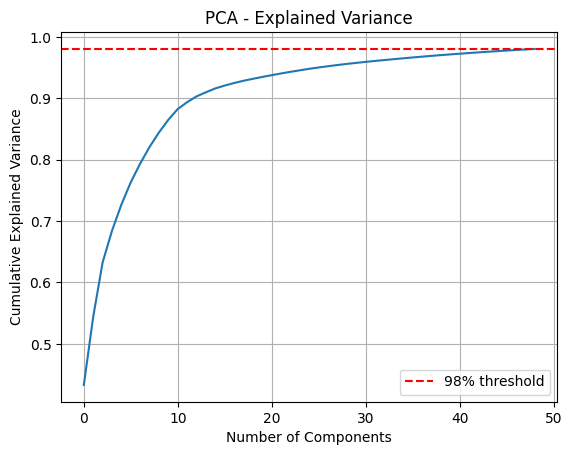

In [52]:
# Import the Requried  Dependencies 
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import numpy as np

# Preparation for training and feature selection 
X = sample_df.drop("Cluster",axis= 1)
y = sample_df["Cluster"]


# Principal Compoment Analyssis - Is a way to shrink the dimensionality of the dataset
# PCA allows us to keep the most relevant feature only, we can either explicitly  mention the number of columms we want to keep or  give it percentage preserve the variance


#Splitng the data in test and train 
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.2,random_state= 30)


# Find the best percentage of data to keep while reducing the number of features

variance_list = [0.80,0.85,0.90,0.95,0.98,0.99]

for variance in variance_list:
    pca = PCA(variance)
    X_train_pca = pca.fit_transform(X_train)
    print(f"Components with {int(variance * 100)}% variance: {X_train_pca.shape[1]}")
    
# Keeping 98% percent of the variance
pca = PCA(0.98)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance')
plt.axhline(y=0.98, color='r', linestyle='--', label='98% threshold')
plt.grid(True)
plt.legend()
plt.show()
 

In [54]:
# Import the Requried  Dependencies 
from sklearn.model_selection import train_test_split, GridSearchCV,KFold,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.metrics import log_loss, classification_report

# Selecting Parameter for GridSearchCV
model_prams = {
    "svm": {
        'model': svm.SVC(probability=True),
        'params':{
             'C': [ 0.01, 0.1,1]
        }  
    },
    "randomForest":{
        'model': RandomForestClassifier(),
        'params':{
            'n_estimators': [10,20,50],
            'max_depth':[4,8,15]
        }
    },
    
    "logistic_regression":{
        'model': LogisticRegression(max_iter= 1000),
        'params': {
             'C': [ 0.01, 0.1,1]
        }
    }
}

scores =[]
best_estimators = {}
for algo, mp in model_prams.items():
    print(f"Training: {algo}")
    
    clf = GridSearchCV(mp["model"],mp["params"],cv=5, n_jobs=-1,return_train_score=True,  scoring='neg_log_loss')
    model =clf.fit(X_train,y_train)
    best_estimators[algo] = clf.best_estimator_
    
    
    
    y_pred = clf.predict(X_test)
    
    y_proba_train = clf.predict_proba(X_train)
    y_proba_test = clf.predict_proba(X_test)
    
    
    train_loss =log_loss(y_train,y_proba_train)
    test_loss =log_loss(y_test,y_proba_test)
    
    
    print(f"\n=== {algo.upper()} ===")
    print(f"Best Params: {clf.best_params_}")
    print(f"Best Params Train Loss:{train_loss}")
    print(f"Best Params Test Loss: {test_loss}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
   
    # Loss
    # Extract and convert to actual (positive) loss
    train_losses = -clf.cv_results_['mean_train_score']
    test_losses = -clf.cv_results_['mean_test_score']
    params = clf.cv_results_['params']

    
    for i in range(len(params)):
         print(f"Params: {params[i]}")
         print(f"→ Train Loss: {train_losses[i]:.4f}, Test Loss: {test_losses[i]:.4f}\n")


Training: svm

=== SVM ===
Best Params: {'C': 1}
Best Params Train Loss:0.08926619446026965
Best Params Test Loss: 0.11460885980562374
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       653
           1       0.98      0.96      0.97       666
           2       0.94      1.00      0.97       681

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000

Params: {'C': 0.01}
→ Train Loss: 0.5482, Test Loss: 0.5545

Params: {'C': 0.1}
→ Train Loss: 0.2889, Test Loss: 0.2988

Params: {'C': 1}
→ Train Loss: 0.0961, Test Loss: 0.1066

Training: randomForest

=== RANDOMFOREST ===
Best Params: {'max_depth': 15, 'n_estimators': 50}
Best Params Train Loss:0.10047176439044223
Best Params Test Loss: 0.12442433355166448
Classification Report:
              precision    recall  f1-score   support

           0       1.0

array([[602,  11,  40],
       [  5, 661,   0],
       [  0,   0, 681]])

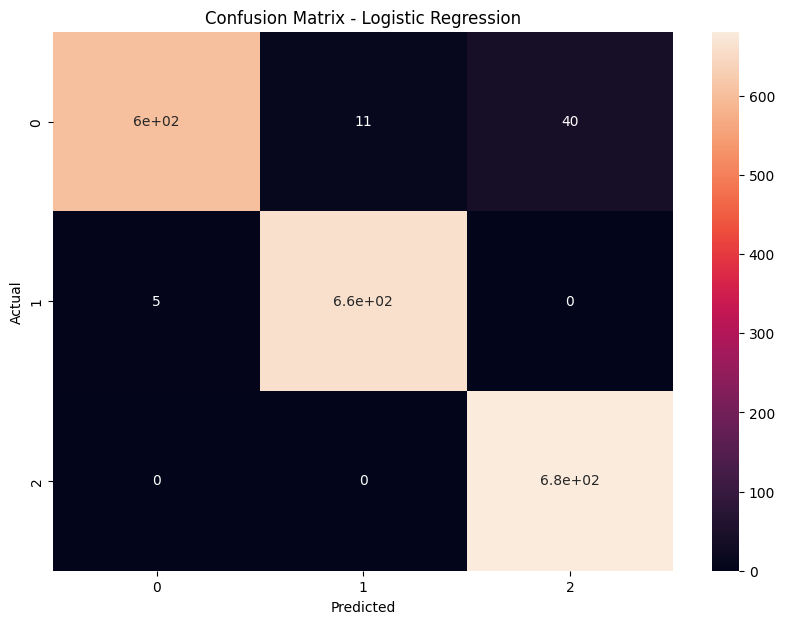

In [24]:
# Import the requried  Dependencies 
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Drawing Confusing Matrix
best_clf = best_estimators['randomForest']
cm = confusion_matrix(y_test, best_clf.predict(X_test))

# Plot
plt.figure(figsize = (10,7))
sns.heatmap(cm,annot= True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')


cm

In [35]:


X_final = full_df.drop("Cluster",axis= 1)
y_final  = full_df["Cluster"]

#Splitng the data in test and train 
X_train, X_test, y_train, y_test = train_test_split(X_final,y_final,test_size= 0.2,random_state= 30)

# Keeping 95% percent of the variance
pca = PCA(0.98)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


# Initialize logistic regression model
model = best_estimators['logistic_regression']

# Define 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate using cross-validation
scores = cross_val_score(model, X_train_pca, y_train, cv=kfold, scoring='accuracy')

# Print scores
print("Cross-validated scores:", scores)
print("Mean accuracy:", scores.mean())

# Now train on full training set and evaluate on test set
model.fit(X_train_pca, y_train)

y_pred_test = model.predict(X_test_pca)
y_pred_train = model.predict(X_train_pca)

# Classification report Test
print("\nClassification Report Test Set :\n", classification_report(y_test, y_pred_test))

# Classification report Test
print("\nClassification Report Train Set :\n", classification_report(y_train, y_pred_train))


Cross-validated scores: [0.9758426  0.97516378 0.97651603 0.9759719  0.97560016]
Mean accuracy: 0.9758188949228515

Classification Report Test Set :
               precision    recall  f1-score   support

           0       0.98      0.95      0.97     77153
           1       0.98      0.99      0.99     77158
           2       0.97      0.99      0.98     77709

    accuracy                           0.98    232020
   macro avg       0.98      0.98      0.98    232020
weighted avg       0.98      0.98      0.98    232020


Classification Report Test Set :
               precision    recall  f1-score   support

           0       0.98      0.95      0.96    309547
           1       0.98      0.99      0.99    309542
           2       0.97      0.99      0.98    308991

    accuracy                           0.98    928080
   macro avg       0.98      0.98      0.98    928080
weighted avg       0.98      0.98      0.98    928080



array([[73320,  1432,  2401],
       [  558, 76597,     3],
       [  915,     1, 76793]])

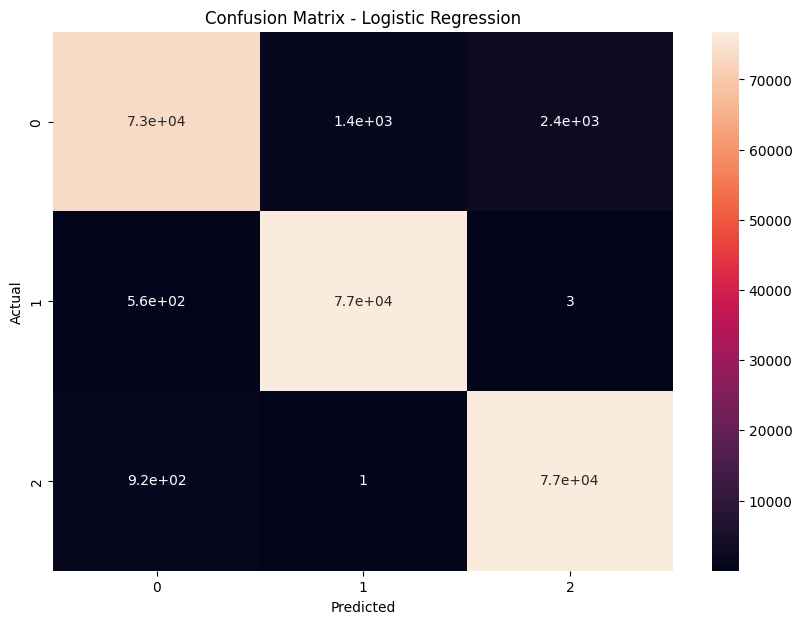

In [38]:
# Drawing Confusing Matrix

cm = confusion_matrix(y_test, model.predict(X_test_pca))

# Plot
plt.figure(figsize = (10,7))
sns.heatmap(cm,annot= True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')

cm

In [18]:
# Saving Model 
import joblib 
joblib.dump(model,"model_version_1.pk1")

['model_version_1.pk1']